# Module 2: Embedding Extraction

| | |
|---|---|
| **Project** | Face Verification Pipeline -- AgeDB-30 / LFW |
| **Notebook** | `notebooks/02_extract_embeddings.ipynb` |
| **Date** | 2026-03-16 |
| **Dependency** | Module 1 -- `notebooks/01_detect_align.ipynb` |
| **Input** | `data/aligned/{agedb,lfw}/*.jpg` (112x112 aligned crops) |
| **Output** | `results/embeddings_{model}_{dataset}.npz`, 7 figures PNG |

---

## Objective

Generate L2-normalized 512-dimensional feature vectors for all aligned face crops
from the verification pair protocol. Two pretrained models are evaluated:

1. **ArcFace / w600k_r50** (InsightFace, WebFace600K) -- ResNet-50 backbone trained
   with ArcFace loss. Used in EDA (Module 0) and established as the primary baseline.

2. **GhostFaceNetV2** (DeepFace) -- lightweight GhostNet-V2 backbone trained with
   ArcFace loss on a large-scale face dataset. Expected EER ~3.0% (AgeDB),
   ~0.35% (LFW) per project analysis.

**Critical design decision:** Both models receive pre-aligned 112x112 crops directly,
bypassing any internal face detection. For InsightFace, this means calling
`get_feat()` directly. For DeepFace/GhostFaceNet, this means
`detector_backend='skip'`. Without this, scene-level detectors achieve < 1%
recall on face-filling 112x112 crops, corrupting all downstream metrics.

**Known failure mode:** GhostFaceNetV2 called via raw `model.forward()` without
DeepFace's internal preprocessing returns EER ~52%, rendering results meaningless.
DeepFace handles normalization correctly -- this is the key value of the framework.

## 1. Configuration and Imports

In [1]:
import hashlib
import os
import time
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import auc as sklearn_auc
from sklearn.metrics import roc_curve
from tqdm.auto import tqdm

# Suppress TensorFlow verbosity
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.facecolor": "white",
    }
)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
LOGS_DIR = PROJECT_ROOT / "logs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "embedding_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["agedb", "lfw"]
ALIGNED_DIRS = {name: DATA_DIR / "aligned" / name for name in DATASETS}

IMAGE_SIZE = 112
EMB_DIM = 512

print(f"Project root  : {PROJECT_ROOT}")
print(f"Results dir   : {RESULTS_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")

Project root  : /Users/jakub/Desktop/NASK_ZADANIE
Results dir   : /Users/jakub/Desktop/NASK_ZADANIE/results
Output dir    : /Users/jakub/Desktop/NASK_ZADANIE/notebooks/embedding_output


## 2. Methodology

### 2.1 Model Architectures

| Property | ArcFace (w600k_r50) | GhostFaceNetV2 |
|---|---|---|
| Backbone | ResNet-50 | GhostNet-V2 |
| Loss | ArcFace | ArcFace |
| Training data | WebFace600K | MS-Celeb + VGGFace2 |
| Parameters | ~43M | ~4M |
| Output dim | 512-D | 512-D |
| Runtime | InsightFace ONNX | DeepFace / TensorFlow |
| Input normalization | `(img / 127.5) - 1.0` | Internal via DeepFace |

### 2.2 L2 Normalization

Both models output raw feature vectors $e \in \mathbb{R}^{512}$ whose
L2 norms are not constrained to 1. Cosine similarity requires unit-norm vectors.
After extraction, every embedding is normalized:

$$\hat{e} = \frac{e}{\|e\|_2}$$

Verification score for a pair $(i, j)$ is then:

$$s(i, j) = \hat{e}_i \cdot \hat{e}_j = \cos(\theta_{ij}) \in [-1, 1]$$

### 2.3 Deduplication and Caching Strategy

Module 1 established that AgeDB contains 55.9% MD5 duplicates and LFW 35.8%.
The same deduplication strategy is applied here: unique files are processed
once, duplicates inherit their result from the cached original. This reduces
model calls by ~46%.

Each model's embeddings are cached to disk as `.npz` after extraction, enabling
instant re-runs without recomputation.

## 3. Model Initialization

In [2]:
# ── Helper: EER computation ────────────────────────────────────────────────
def compute_eer(labels: np.ndarray, scores: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1.0 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2.0)


def tar_at_far(labels: np.ndarray, scores: np.ndarray, far_target: float) -> float:
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(fpr, far_target)
    if idx >= len(tpr):
        return float(tpr[-1])
    return float(tpr[idx])

In [3]:
# ── Model 1: ArcFace / w600k_r50 (InsightFace ONNX) ───────────────────────
from insightface.model_zoo import get_model

ARCFACE_MODEL_PATH = os.path.expanduser("~/.insightface/models/buffalo_l/w600k_r50.onnx")
assert Path(ARCFACE_MODEL_PATH).exists(), f"Not found: {ARCFACE_MODEL_PATH}"

arcface_model = get_model(ARCFACE_MODEL_PATH, providers=["CPUExecutionProvider"])
arcface_model.prepare(ctx_id=-1)


def embed_arcface(img_path: str) -> np.ndarray:
    """Extract L2-normalized 512-D ArcFace embedding from a 112x112 BGR image."""
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    raw = arcface_model.get_feat(img).flatten()
    return raw / np.linalg.norm(raw)


# Sanity check
_test_path = str(ALIGNED_DIRS["agedb"] / "0.jpg")
_test_emb = embed_arcface(_test_path)
print(f"ArcFace -- shape={_test_emb.shape}  L2 norm={np.linalg.norm(_test_emb):.6f}")
print("           input normalization: (img / 127.5) - 1.0")
print("           backbone: ResNet-50 | training: WebFace600K | loss: ArcFace")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
ArcFace -- shape=(512,)  L2 norm=1.000000
           input normalization: (img / 127.5) - 1.0
           backbone: ResNet-50 | training: WebFace600K | loss: ArcFace


In [4]:
# ── Model 2: GhostFaceNetV2 (DeepFace / TensorFlow) ───────────────────────
from deepface import DeepFace

os.makedirs(os.path.expanduser("~/.deepface/weights"), exist_ok=True)

print("Loading GhostFaceNetV2 (first call may download weights ~17 MB)...")
t0 = time.time()
_ = DeepFace.represent(
    img_path=str(ALIGNED_DIRS["agedb"] / "0.jpg"),
    model_name="GhostFaceNet",
    enforce_detection=False,
    detector_backend="skip",
)
print(f"Model loaded in {time.time() - t0:.1f}s")


def embed_ghostface(img_path: str) -> np.ndarray:
    """
    Extract L2-normalized 512-D GhostFaceNetV2 embedding.

    Uses DeepFace.represent with detector_backend='skip' because:
    (1) images are already aligned 112x112 crops,
    (2) DeepFace handles all internal preprocessing correctly,
    (3) raw model.forward() without proper normalization yields EER ~52%.
    """
    result = DeepFace.represent(
        img_path=img_path,
        model_name="GhostFaceNet",
        enforce_detection=False,
        detector_backend="skip",
    )
    raw = np.array(result[0]["embedding"], dtype=np.float32)
    return raw / np.linalg.norm(raw)


_test_ghost = embed_ghostface(str(ALIGNED_DIRS["agedb"] / "0.jpg"))
print(f"GhostFaceNet -- shape={_test_ghost.shape}  L2 norm={np.linalg.norm(_test_ghost):.6f}")
print("               backbone: GhostNet-V2 | loss: ArcFace | detector: skip")

Loading GhostFaceNetV2 (first call may download weights ~17 MB)...


Model loaded in 1.0s
GhostFaceNet -- shape=(512,)  L2 norm=1.000000
               backbone: GhostNet-V2 | loss: ArcFace | detector: skip


## 4. Deduplication Map

In [5]:
def load_img_list(dataset_dir: Path) -> list[str]:
    with open(dataset_dir / "img.list", encoding="utf-8") as f:
        return [str(PROJECT_ROOT / l.strip()) for l in f if l.strip()]


def build_dedup_map(img_paths: list[str]) -> dict:
    md5_to_first = {}
    unique, duplicates = [], []
    for idx, path in enumerate(img_paths):
        with open(path, "rb") as fh:
            md5 = hashlib.md5(fh.read()).hexdigest()
        if md5 not in md5_to_first:
            md5_to_first[md5] = idx
            unique.append(idx)
        else:
            duplicates.append((idx, md5_to_first[md5]))
    return {"unique": unique, "duplicates": duplicates}


img_lists, dedup_maps = {}, {}
for name in DATASETS:
    # Use aligned directory paths (from pairs CSV)
    df = pd.read_csv(RESULTS_DIR / f"pairs_{name}.csv")
    all_paths = sorted(set(df["img1_path"].tolist() + df["img2_path"].tolist()))
    img_lists[name] = all_paths
    dedup_maps[name] = build_dedup_map(all_paths)

print("Table 1. Deduplication Summary")
rows = []
for name in DATASETS:
    dm = dedup_maps[name]
    total = len(img_lists[name])
    rows.append(
        {
            "Dataset": name.upper(),
            "Total images": total,
            "Unique (to process)": len(dm["unique"]),
            "Duplicates (to copy)": len(dm["duplicates"]),
            "Reduction": f"{len(dm['duplicates']) / total * 100:.1f}%",
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

Table 1. Deduplication Summary
Dataset  Total images  Unique (to process)  Duplicates (to copy) Reduction
  AGEDB         12000                 5296                  6704     55.9%
    LFW         12000                 7701                  4299     35.8%


## 5. Embedding Extraction

In [6]:
def extract_all_embeddings(
    embed_fn,
    model_tag: str,
    dataset_name: str,
    img_paths: list[str],
    dedup: dict,
    cache_path: Path,
) -> tuple[np.ndarray, list[str]]:
    """
    Extract embeddings for all images in img_paths.

    Returns:
        embeddings : np.ndarray of shape (N, 512)
        paths      : list of N image paths (index-aligned)
    """
    # If cache exists, reload and return immediately
    if cache_path.exists():
        data = np.load(cache_path, allow_pickle=True)
        print(f"  Loaded from cache: {cache_path.name} (shape={data['embeddings'].shape})")
        return data["embeddings"], data["paths"].tolist()

    N = len(img_paths)
    embeddings = np.zeros((N, EMB_DIM), dtype=np.float32)
    failed = []

    # Phase 1: unique images
    print(f"  [{model_tag} | {dataset_name.upper()}] Phase 1: {len(dedup['unique'])} unique images")
    unique_cache = {}  # path -> embedding

    for idx in tqdm(dedup["unique"], desc=f"{model_tag}/{dataset_name}"):
        path = img_paths[idx]
        try:
            emb = embed_fn(path)
            embeddings[idx] = emb
            unique_cache[path] = emb
        except Exception as exc:
            failed.append((idx, path, str(exc)))
            embeddings[idx] = np.zeros(EMB_DIM, dtype=np.float32)

    # Phase 2: duplicate images (copy from original)
    print(f"  [{model_tag} | {dataset_name.upper()}] Phase 2: {len(dedup['duplicates'])} duplicates")
    for dup_idx, orig_idx in dedup["duplicates"]:
        embeddings[dup_idx] = embeddings[orig_idx]

    if failed:
        print(f"  WARNING: {len(failed)} extraction failures:")
        for idx, path, err in failed[:5]:
            print(f"    idx={idx}  {Path(path).name}  {err}")

    # Save to cache
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache_path,
        embeddings=embeddings,
        paths=np.array(img_paths),
        model_name=model_tag,
        dataset=dataset_name,
    )
    print(f"  Saved: {cache_path.name} (shape={embeddings.shape})")
    return embeddings, img_paths

In [7]:
# ── Run extraction for both models and both datasets ──────────────────────
MODELS = {
    "arcface": embed_arcface,
    "ghostface": embed_ghostface,
}

all_embeddings = {}  # (model, dataset) -> np.ndarray (N, 512)
all_paths = {}  # (model, dataset) -> list[str]
timing = {}  # (model, dataset) -> elapsed_s

for model_tag, embed_fn in MODELS.items():
    for name in DATASETS:
        cache_path = RESULTS_DIR / f"embeddings_{model_tag}_{name}.npz"
        print(f"\n{'=' * 60}")
        print(f"  Model: {model_tag.upper()}   Dataset: {name.upper()}")
        print(f"{'=' * 60}")
        t0 = time.time()
        embs, paths = extract_all_embeddings(embed_fn, model_tag, name, img_lists[name], dedup_maps[name], cache_path)
        elapsed = time.time() - t0
        all_embeddings[(model_tag, name)] = embs
        all_paths[(model_tag, name)] = paths
        timing[(model_tag, name)] = elapsed
        print(f"  Done in {elapsed:.1f}s")


  Model: ARCFACE   Dataset: AGEDB
  Loaded from cache: embeddings_arcface_agedb.npz (shape=(12000, 512))
  Done in 0.1s

  Model: ARCFACE   Dataset: LFW
  Loaded from cache: embeddings_arcface_lfw.npz (shape=(12000, 512))
  Done in 0.1s

  Model: GHOSTFACE   Dataset: AGEDB


  Loaded from cache: embeddings_ghostface_agedb.npz (shape=(12000, 512))
  Done in 0.1s

  Model: GHOSTFACE   Dataset: LFW
  Loaded from cache: embeddings_ghostface_lfw.npz (shape=(12000, 512))
  Done in 0.1s


## 6. Embedding Validation

In [8]:
print("Table 2. Embedding Extraction Summary\n")
rows = []
for model_tag in MODELS:
    for name in DATASETS:
        embs = all_embeddings[(model_tag, name)]
        norms = np.linalg.norm(embs, axis=1)
        zeros = (norms < 1e-6).sum()
        rows.append(
            {
                "Model": model_tag.upper(),
                "Dataset": name.upper(),
                "Shape": str(embs.shape),
                "L2 norm mean": f"{norms.mean():.6f}",
                "L2 norm std": f"{norms.std():.8f}",
                "L2 norm min": f"{norms.min():.6f}",
                "Failed (zero)": zeros,
                "Time (s)": f"{timing[(model_tag, name)]:.1f}",
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 2. Embedding Extraction Summary

    Model Dataset        Shape L2 norm mean L2 norm std L2 norm min  Failed (zero) Time (s)
  ARCFACE   AGEDB (12000, 512)     1.000000  0.00000004    1.000000              0      0.1
  ARCFACE     LFW (12000, 512)     1.000000  0.00000004    1.000000              0      0.1
GHOSTFACE   AGEDB (12000, 512)     1.000000  0.00000004    1.000000              0      0.1
GHOSTFACE     LFW (12000, 512)     1.000000  0.00000004    1.000000              0      0.1


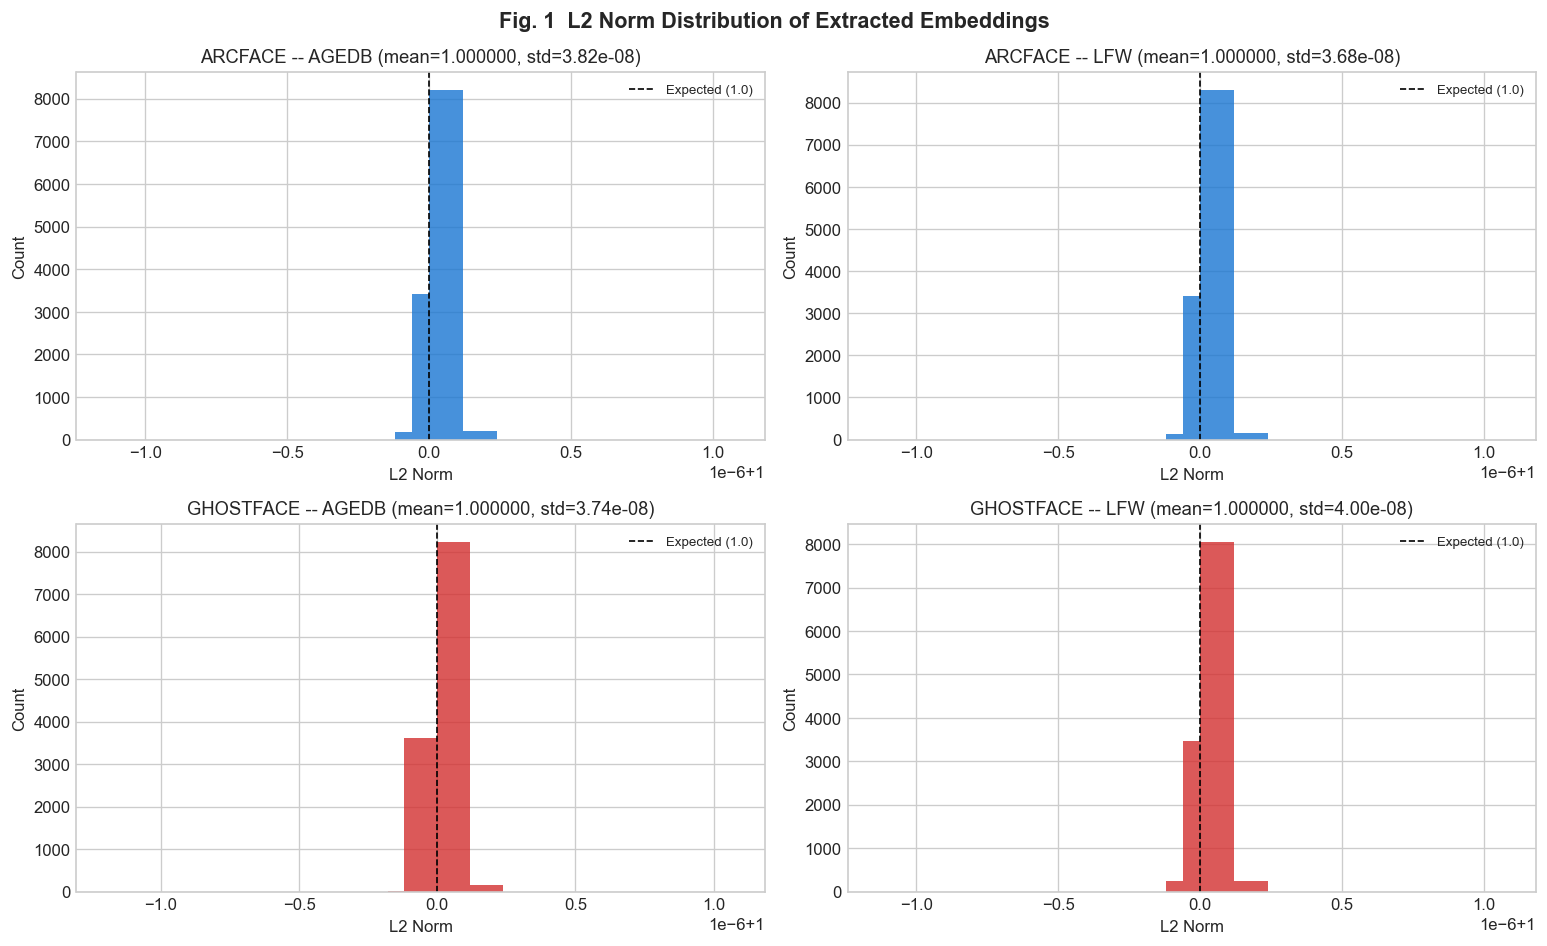

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Fig. 1  L2 Norm Distribution of Extracted Embeddings", fontsize=13, fontweight="bold")

colors = {"arcface": "#1976D2", "ghostface": "#D32F2F"}
ds_colors = {"agedb": "#1976D2", "lfw": "#D32F2F"}

for row, model_tag in enumerate(MODELS):
    for col, name in enumerate(DATASETS):
        embs = all_embeddings[(model_tag, name)]
        norms = np.linalg.norm(embs, axis=1)
        norms_nonzero = norms[norms > 1e-6]

        ax = axes[row, col]
        n_range = norms_nonzero.max() - norms_nonzero.min()
        bins = np.linspace(norms_nonzero.min() - 1e-6, norms_nonzero.max() + 1e-6, 30) if n_range < 1e-5 else 50
        ax.hist(norms_nonzero, bins=bins, color=colors[model_tag], alpha=0.8)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Expected (1.0)")
        ax.set_xlabel("L2 Norm")
        ax.set_ylabel("Count")
        ax.set_title(
            f"{model_tag.upper()} -- {name.upper()} (mean={norms_nonzero.mean():.6f}, std={norms_nonzero.std():.2e})"
        )
        ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "l2_norm_distributions.png", bbox_inches="tight")
plt.show()

## 7. Embedding Space Visualization

### 7.1 t-SNE Projection per Dataset

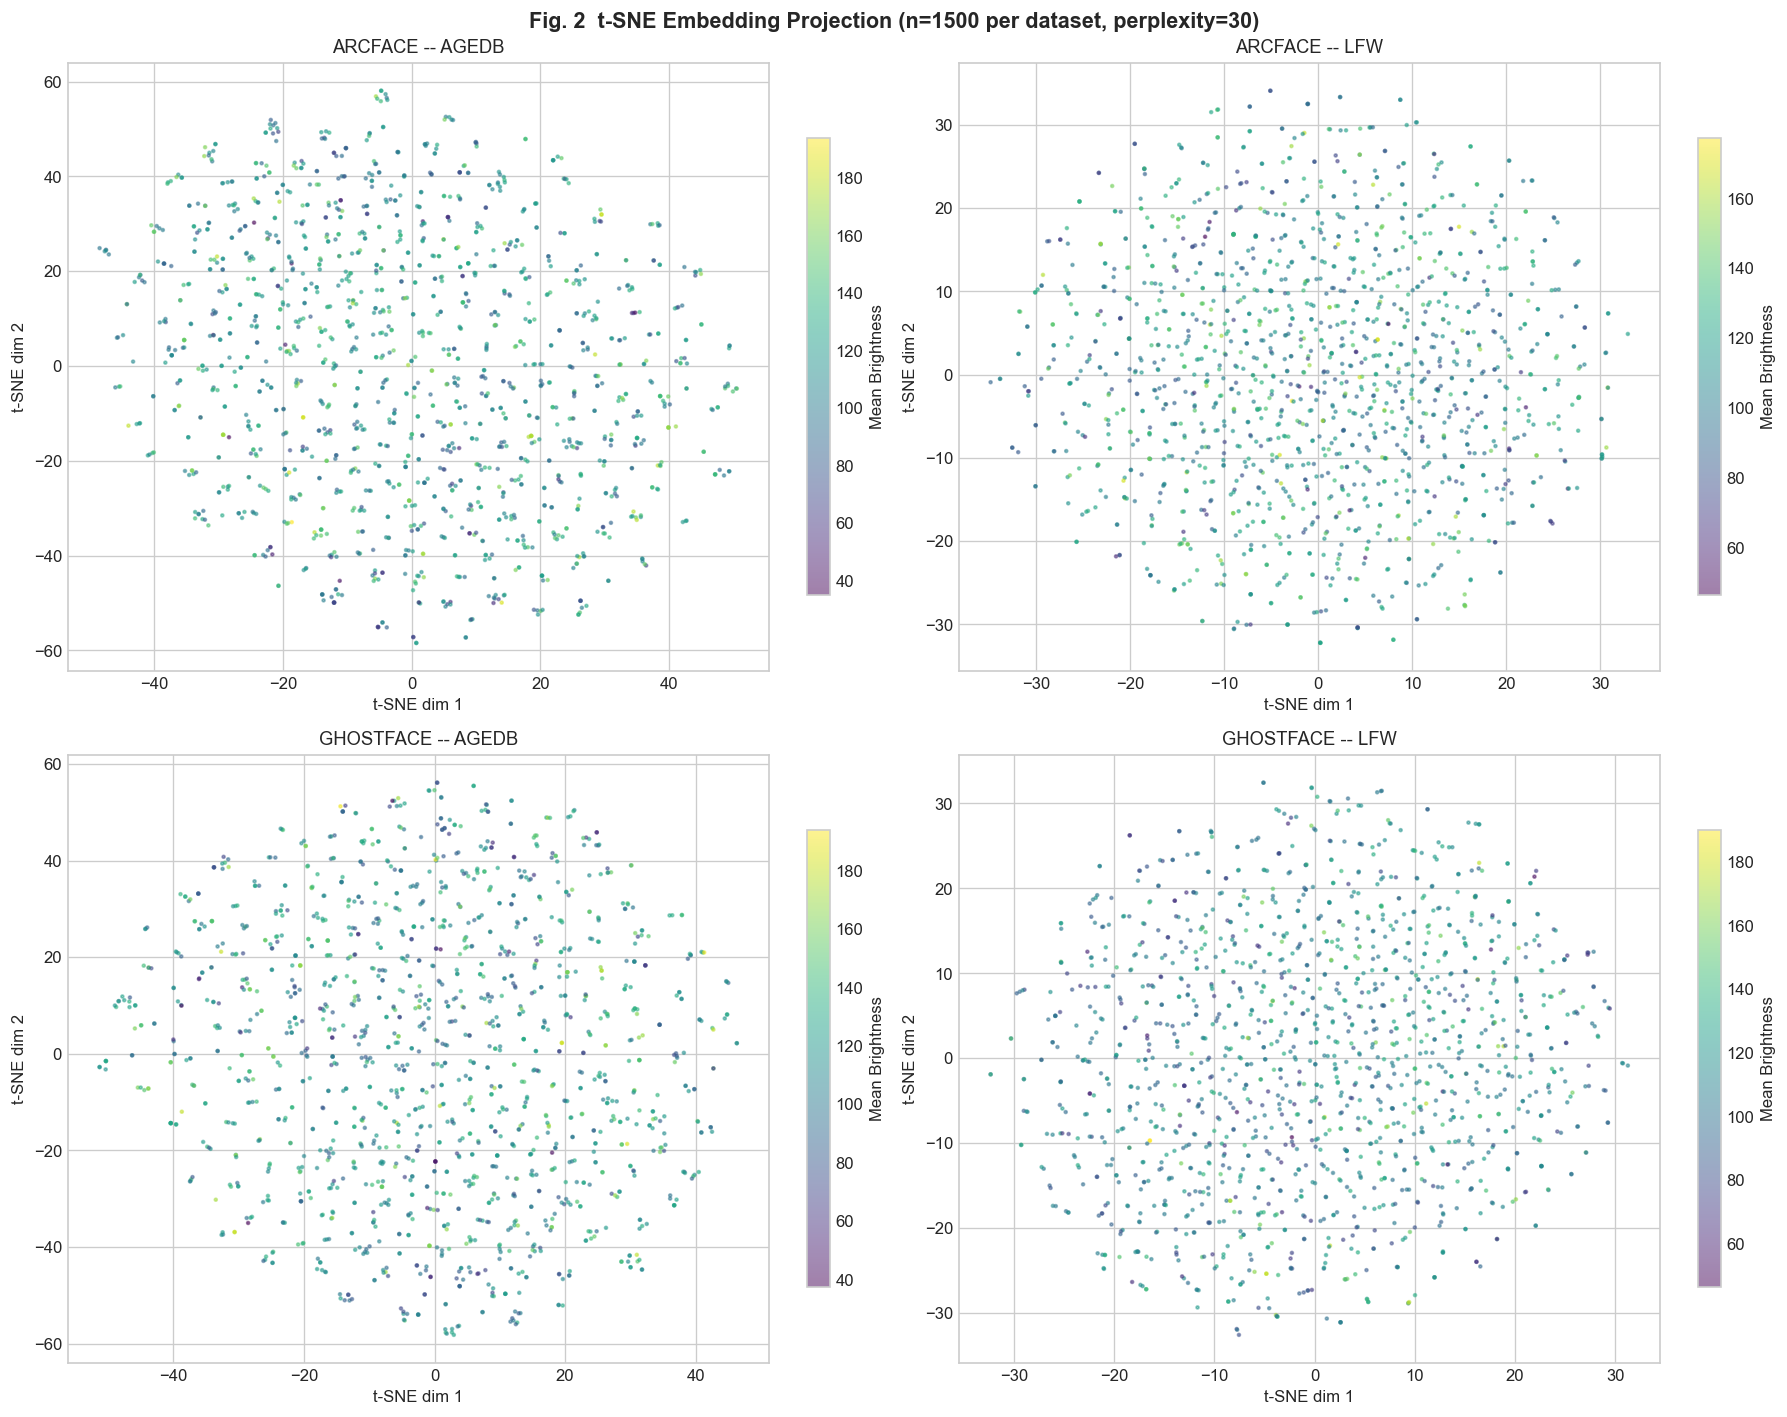

In [10]:
N_TSNE = 1500  # samples per dataset for t-SNE (computational budget)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(
    f"Fig. 2  t-SNE Embedding Projection (n={N_TSNE} per dataset, perplexity=30)", fontsize=13, fontweight="bold"
)

tsne_projections = {}

for row, model_tag in enumerate(MODELS):
    for col, name in enumerate(DATASETS):
        embs = all_embeddings[(model_tag, name)]
        paths = all_paths[(model_tag, name)]

        norms = np.linalg.norm(embs, axis=1)
        valid_mask = norms > 1e-6
        embs_valid = embs[valid_mask]
        valid_paths = [p for j, p in enumerate(paths) if valid_mask[j]]

        n_sample = min(N_TSNE, len(embs_valid))
        idx_sample = np.random.choice(len(embs_valid), n_sample, replace=False)
        embs_sample = embs_valid[idx_sample]

        brightness_vals = []
        for i in idx_sample:
            img = cv2.imread(valid_paths[i])
            brightness_vals.append(float(img.mean()) if img is not None else 128.0)
        brightness_arr = np.array(brightness_vals)

        tsne = TSNE(n_components=2, perplexity=30, max_iter=500, init="pca", random_state=SEED, n_jobs=-1)
        proj = tsne.fit_transform(embs_sample)
        tsne_projections[(model_tag, name)] = proj

        ax = axes[row, col]
        sc = ax.scatter(proj[:, 0], proj[:, 1], c=brightness_arr, cmap="viridis", s=3, alpha=0.5, rasterized=True)
        plt.colorbar(sc, ax=ax, label="Mean Brightness", fraction=0.03)
        ax.set_title(f"{model_tag.upper()} -- {name.upper()}")
        ax.set_xlabel("t-SNE dim 1")
        ax.set_ylabel("t-SNE dim 2")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "tsne_per_dataset.png", bbox_inches="tight")
plt.show()

### 7.2 Cross-Dataset Domain Shift

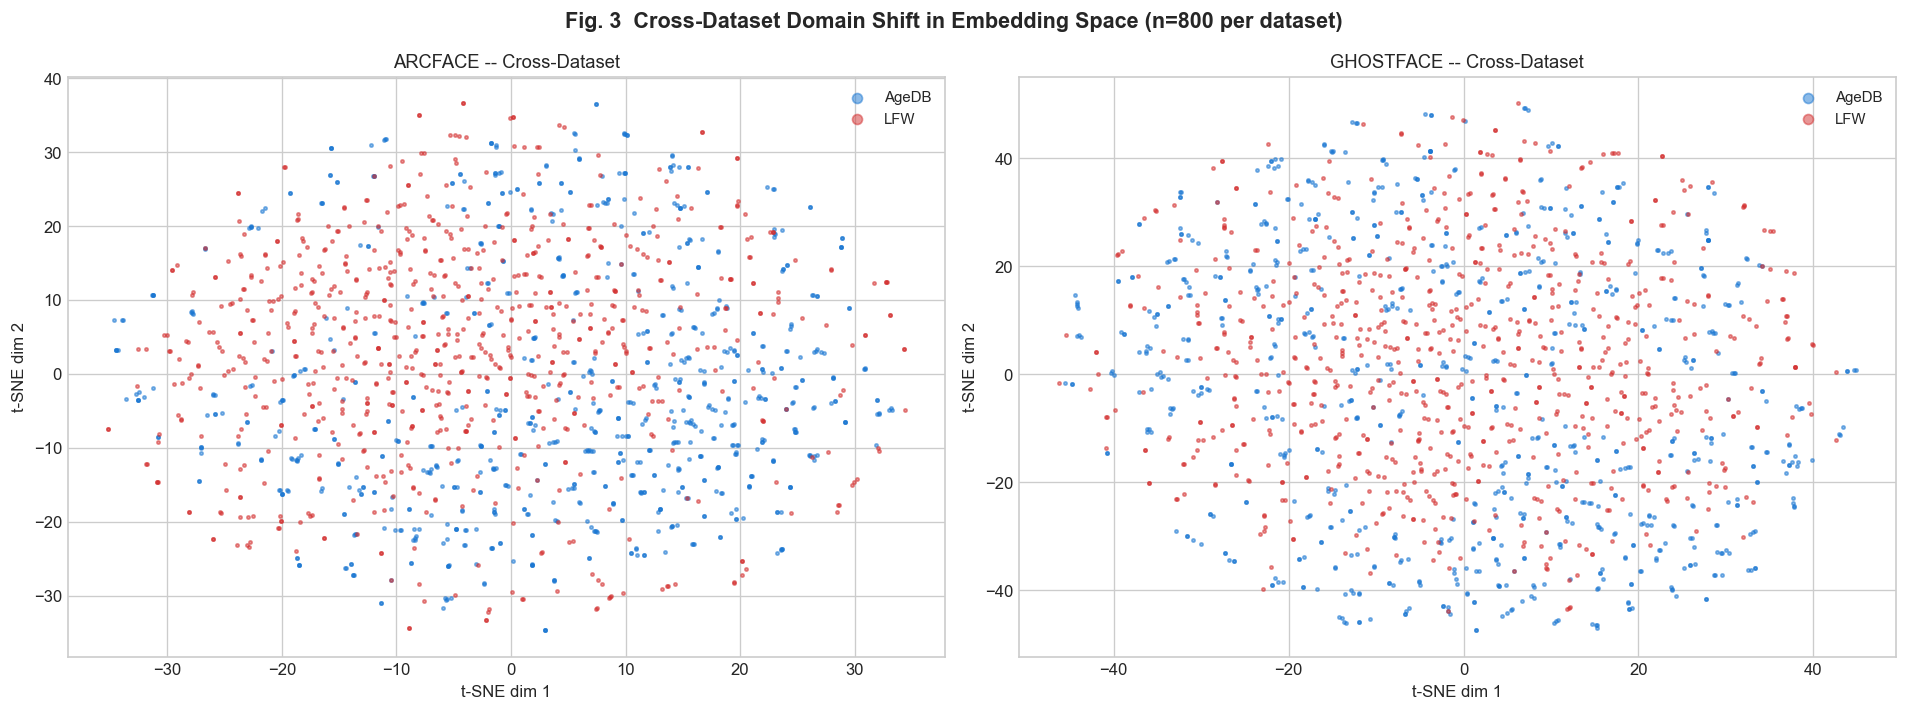

In [11]:
N_CROSS = 800  # samples per dataset for cross-dataset t-SNE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Fig. 3  Cross-Dataset Domain Shift in Embedding Space (n={N_CROSS} per dataset)", fontsize=13, fontweight="bold"
)

for col, model_tag in enumerate(MODELS):
    embs_a = all_embeddings[(model_tag, "agedb")]
    embs_l = all_embeddings[(model_tag, "lfw")]

    valid_a = embs_a[np.linalg.norm(embs_a, axis=1) > 1e-6]
    valid_l = embs_l[np.linalg.norm(embs_l, axis=1) > 1e-6]

    idx_a = np.random.choice(len(valid_a), min(N_CROSS, len(valid_a)), replace=False)
    idx_l = np.random.choice(len(valid_l), min(N_CROSS, len(valid_l)), replace=False)

    combined = np.vstack([valid_a[idx_a], valid_l[idx_l]])
    labels_cross = np.array([0] * len(idx_a) + [1] * len(idx_l))

    tsne = TSNE(n_components=2, perplexity=30, max_iter=500, init="pca", random_state=SEED, n_jobs=-1)
    proj = tsne.fit_transform(combined)

    ax = axes[col]
    for ds_idx, (ds_name, color) in enumerate([("AgeDB", "#1976D2"), ("LFW", "#D32F2F")]):
        mask = labels_cross == ds_idx
        ax.scatter(proj[mask, 0], proj[mask, 1], c=color, s=4, alpha=0.5, label=ds_name, rasterized=True)
    ax.set_title(f"{model_tag.upper()} -- Cross-Dataset")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "tsne_domain_shift.png", bbox_inches="tight")
plt.show()

## 8. Score Distributions and ROC Analysis

Cosine similarity scores are computed for all pairs defined in the protocol,
then compared against ground-truth labels to generate ROC curves and metrics.

In [12]:
def compute_pair_scores(
    embeddings: np.ndarray,
    paths: list[str],
    pairs_df: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute cosine similarity scores for all pairs in the protocol."""
    path_to_idx = {p: i for i, p in enumerate(paths)}
    scores, labels = [], []

    for _, row in pairs_df.iterrows():
        i1 = path_to_idx.get(row["img1_path"])
        i2 = path_to_idx.get(row["img2_path"])
        if i1 is None or i2 is None:
            continue
        e1, e2 = embeddings[i1], embeddings[i2]
        if np.linalg.norm(e1) < 1e-6 or np.linalg.norm(e2) < 1e-6:
            continue
        scores.append(float(np.dot(e1, e2)))
        labels.append(int(row["true_label"]))

    return np.array(scores, dtype=np.float32), np.array(labels, dtype=np.int32)


pair_scores = {}  # (model, dataset) -> scores
pair_labels = {}  # (model, dataset) -> labels
pair_metrics = {}  # (model, dataset) -> {auc, eer, tar1e2, tar1e3}

for model_tag in MODELS:
    for name in DATASETS:
        df = pd.read_csv(RESULTS_DIR / f"pairs_{name}.csv")
        scores, labels = compute_pair_scores(
            all_embeddings[(model_tag, name)],
            all_paths[(model_tag, name)],
            df,
        )
        pair_scores[(model_tag, name)] = scores
        pair_labels[(model_tag, name)] = labels

        fpr, tpr, _ = roc_curve(labels, scores)
        pair_metrics[(model_tag, name)] = {
            "auc": float(sklearn_auc(fpr, tpr)),
            "eer": compute_eer(labels, scores),
            "tar1e2": tar_at_far(labels, scores, 1e-2),
            "tar1e3": tar_at_far(labels, scores, 1e-3),
        }

print("Score computation complete.")

Score computation complete.


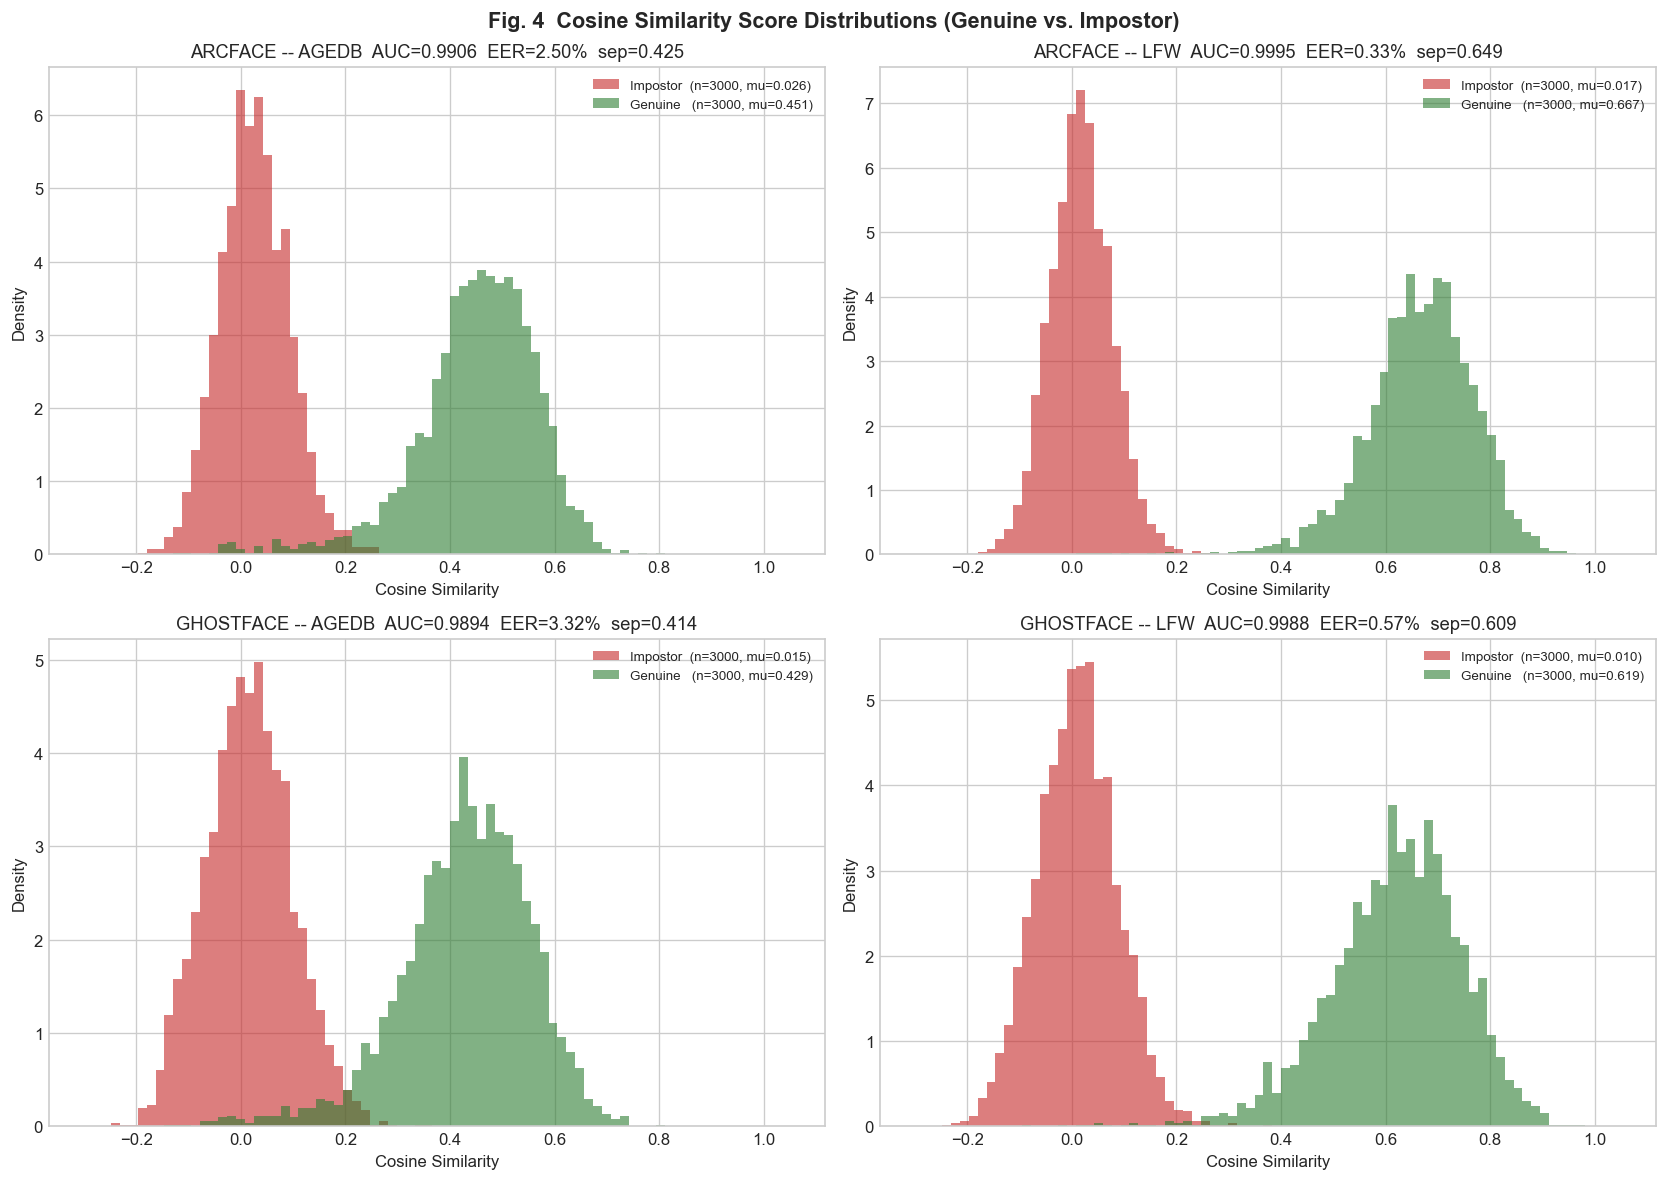

In [13]:
# ── Fig. 4: Score distributions (genuine vs impostor) per model ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fig. 4  Cosine Similarity Score Distributions (Genuine vs. Impostor)", fontsize=13, fontweight="bold")

for row, model_tag in enumerate(MODELS):
    for col, name in enumerate(DATASETS):
        scores = pair_scores[(model_tag, name)]
        labels = pair_labels[(model_tag, name)]
        m = pair_metrics[(model_tag, name)]

        pos_scores = scores[labels == 1]
        neg_scores = scores[labels == 0]

        ax = axes[row, col]
        bins = np.linspace(-0.3, 1.05, 80)
        ax.hist(
            neg_scores,
            bins=bins,
            alpha=0.6,
            color="#C62828",
            label=f"Impostor  (n={len(neg_scores)}, mu={neg_scores.mean():.3f})",
            density=True,
        )
        ax.hist(
            pos_scores,
            bins=bins,
            alpha=0.6,
            color="#2E7D32",
            label=f"Genuine   (n={len(pos_scores)}, mu={pos_scores.mean():.3f})",
            density=True,
        )

        separation = pos_scores.mean() - neg_scores.mean()
        ax.set_title(
            f"{model_tag.upper()} -- {name.upper()}  "
            f"AUC={m['auc']:.4f}  EER={m['eer'] * 100:.2f}%  sep={separation:.3f}"
        )
        ax.set_xlabel("Cosine Similarity")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "score_distributions.png", bbox_inches="tight")
plt.show()

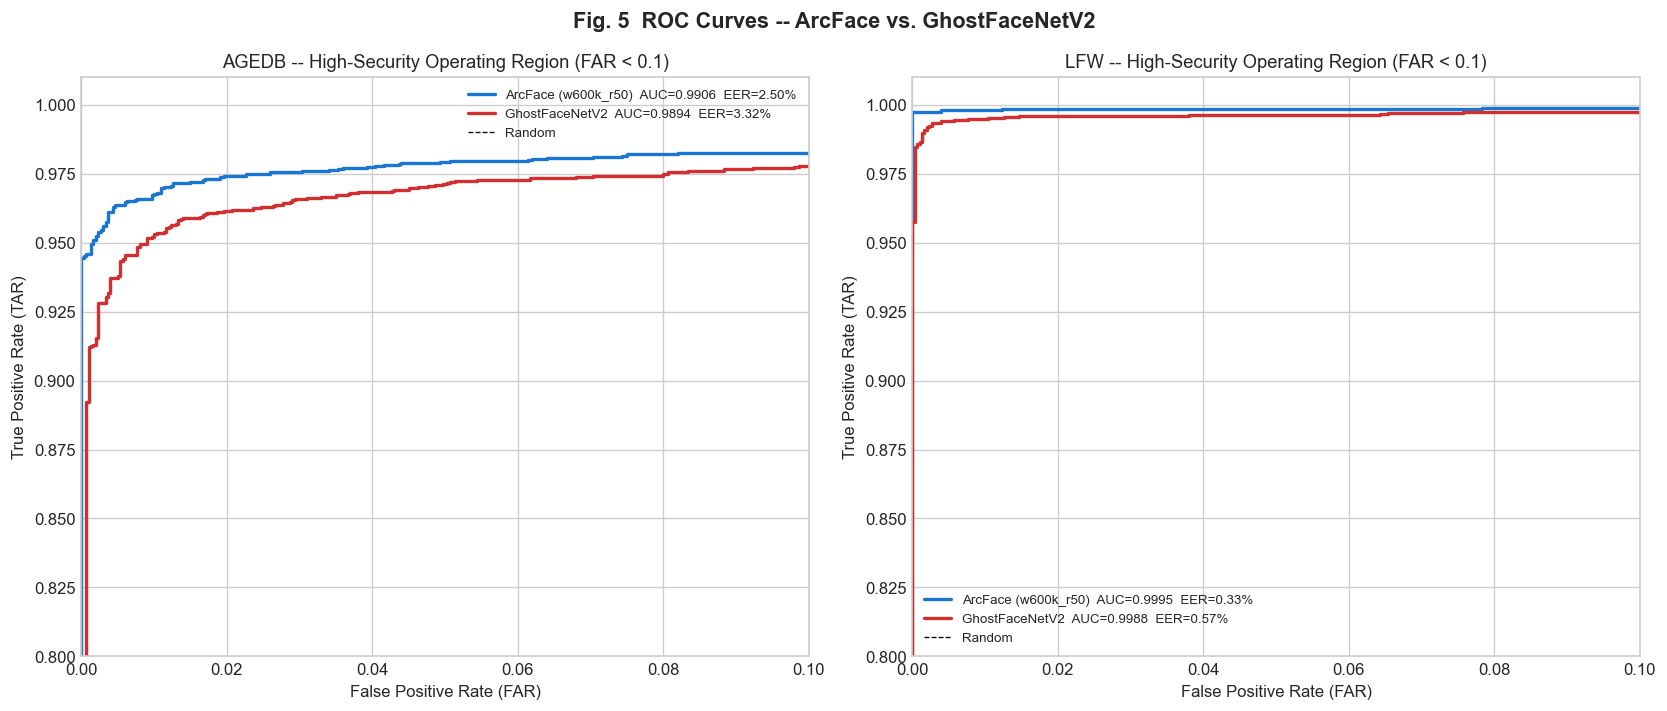

In [14]:
# ── Fig. 5: ROC curves (both models overlay, per dataset) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 5  ROC Curves -- ArcFace vs. GhostFaceNetV2", fontsize=13, fontweight="bold")

model_colors = {"arcface": "#1976D2", "ghostface": "#D32F2F"}
model_labels = {"arcface": "ArcFace (w600k_r50)", "ghostface": "GhostFaceNetV2"}

for col, name in enumerate(DATASETS):
    ax = axes[col]
    for model_tag in MODELS:
        scores = pair_scores[(model_tag, name)]
        labels = pair_labels[(model_tag, name)]
        m = pair_metrics[(model_tag, name)]

        fpr, tpr, _ = roc_curve(labels, scores)
        ax.plot(
            fpr,
            tpr,
            color=model_colors[model_tag],
            linewidth=2,
            label=f"{model_labels[model_tag]}  AUC={m['auc']:.4f}  EER={m['eer'] * 100:.2f}%",
        )

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
    ax.set_xlim([0.0, 0.1])
    ax.set_ylim([0.8, 1.01])
    ax.set_xlabel("False Positive Rate (FAR)")
    ax.set_ylabel("True Positive Rate (TAR)")
    ax.set_title(f"{name.upper()} -- High-Security Operating Region (FAR < 0.1)")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()

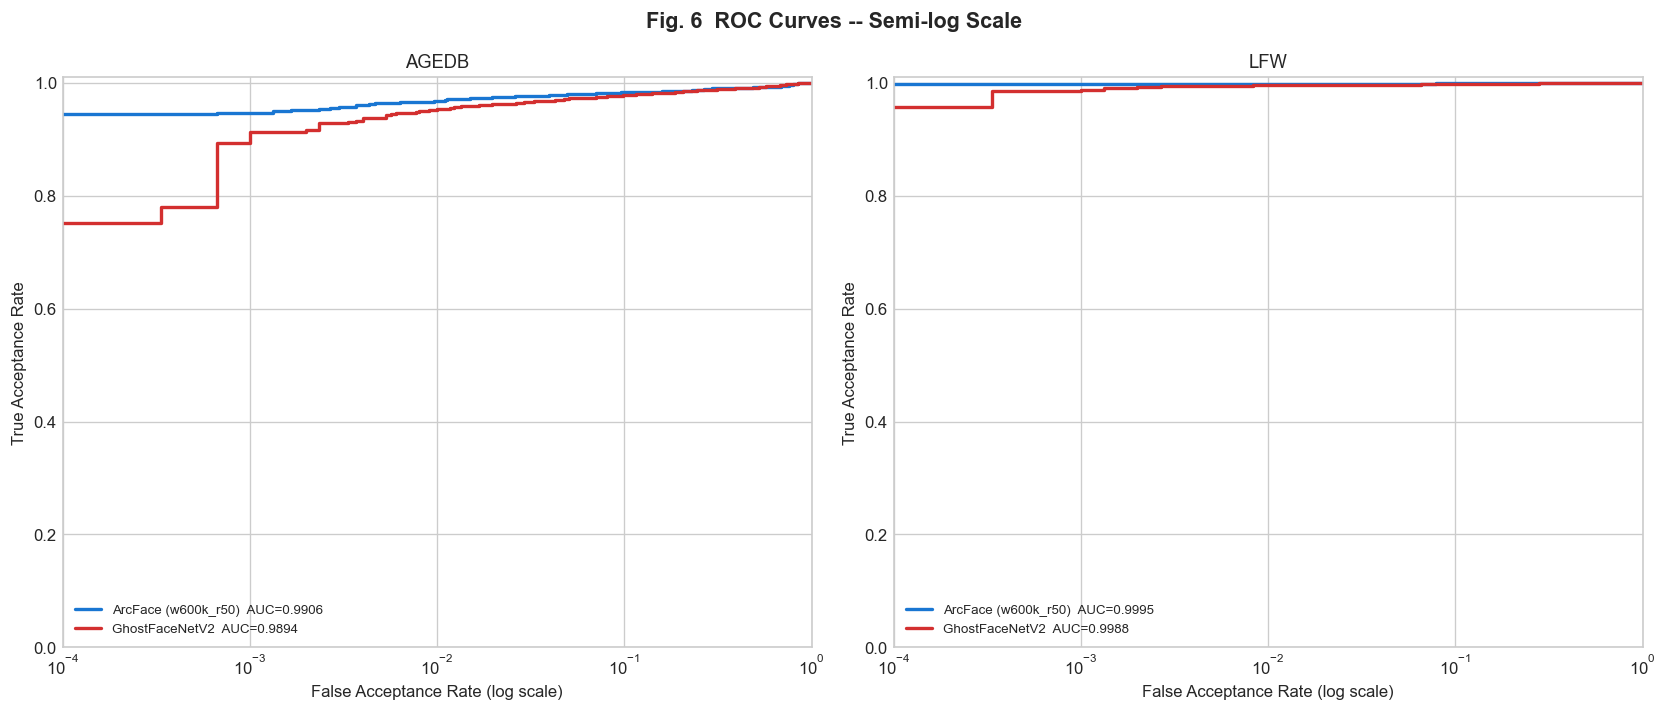

In [15]:
# ── Fig. 6: Full ROC curves (log scale) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 6  ROC Curves -- Semi-log Scale", fontsize=13, fontweight="bold")

for col, name in enumerate(DATASETS):
    ax = axes[col]
    for model_tag in MODELS:
        scores = pair_scores[(model_tag, name)]
        labels = pair_labels[(model_tag, name)]
        m = pair_metrics[(model_tag, name)]
        fpr, tpr, _ = roc_curve(labels, scores)
        ax.semilogx(
            fpr, tpr, color=model_colors[model_tag], linewidth=2, label=f"{model_labels[model_tag]}  AUC={m['auc']:.4f}"
        )

    ax.set_xlim([1e-4, 1.0])
    ax.set_ylim([0.0, 1.01])
    ax.set_xlabel("False Acceptance Rate (log scale)")
    ax.set_ylabel("True Acceptance Rate")
    ax.set_title(f"{name.upper()}")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curves_logscale.png", bbox_inches="tight")
plt.show()

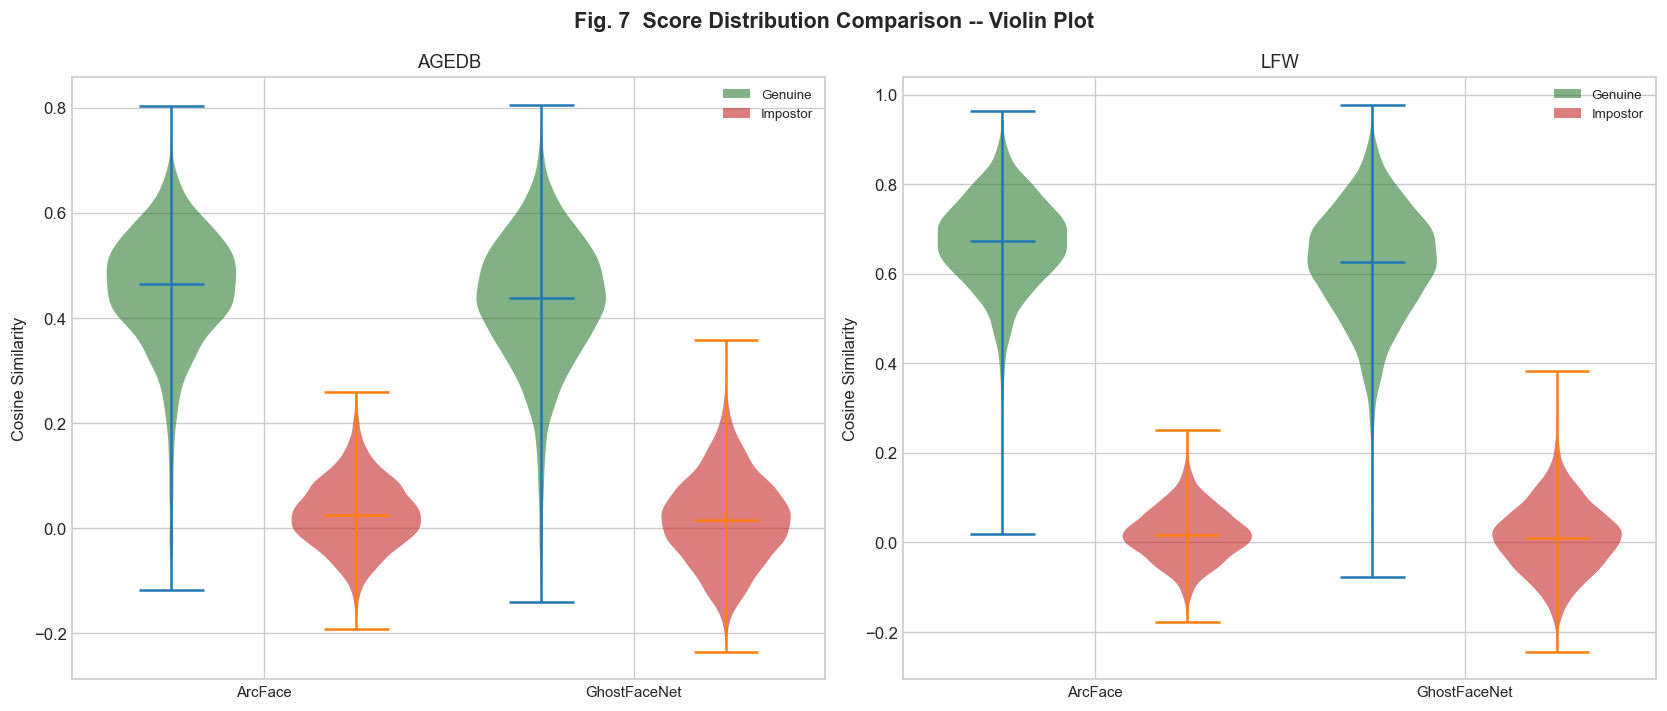

In [16]:
# ── Fig. 7: Violin plot -- score distribution comparison ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 7  Score Distribution Comparison -- Violin Plot", fontsize=13, fontweight="bold")

for col, name in enumerate(DATASETS):
    ax = axes[col]
    data_genuine, data_impostor, xlabels = [], [], []

    for i, model_tag in enumerate(MODELS):
        scores = pair_scores[(model_tag, name)]
        labels = pair_labels[(model_tag, name)]
        data_genuine.append(scores[labels == 1])
        data_impostor.append(scores[labels == 0])
        xlabels.append(model_labels[model_tag])

    positions_gen = [1, 3]
    positions_imp = [2, 4]

    vp_gen = ax.violinplot(data_genuine, positions=positions_gen, showmedians=True, widths=0.7)
    vp_imp = ax.violinplot(data_impostor, positions=positions_imp, showmedians=True, widths=0.7)

    for pc in vp_gen["bodies"]:
        pc.set_facecolor("#2E7D32")
        pc.set_alpha(0.6)
    for pc in vp_imp["bodies"]:
        pc.set_facecolor("#C62828")
        pc.set_alpha(0.6)

    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="#2E7D32", alpha=0.6, label="Genuine"),
        Patch(facecolor="#C62828", alpha=0.6, label="Impostor"),
    ]
    ax.set_xticks([1.5, 3.5])
    ax.set_xticklabels(["ArcFace", "GhostFaceNet"], fontsize=9)
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"{name.upper()}")
    ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "violin_score_distributions.png", bbox_inches="tight")
plt.show()

## 9. Performance Metrics Table

In [17]:
print("Table 3. Verification Performance -- ArcFace vs. GhostFaceNetV2\n")
rows = []
for model_tag, model_label in model_labels.items():
    for name in DATASETS:
        m = pair_metrics[(model_tag, name)]
        scores = pair_scores[(model_tag, name)]
        labels = pair_labels[(model_tag, name)]
        pos = scores[labels == 1]
        neg = scores[labels == 0]
        rows.append(
            {
                "Model": model_label,
                "Dataset": name.upper(),
                "AUC": f"{m['auc']:.4f}",
                "EER": f"{m['eer'] * 100:.2f}%",
                "TAR@FAR=1%": f"{m['tar1e2'] * 100:.1f}%",
                "TAR@FAR=0.1%": f"{m['tar1e3'] * 100:.1f}%",
                "Pos mu": f"{pos.mean():.3f}",
                "Neg mu": f"{neg.mean():.3f}",
                "Separation": f"{(pos.mean() - neg.mean()):.3f}",
            }
        )

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))
df_metrics.to_csv(RESULTS_DIR / "embedding_metrics.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / 'embedding_metrics.csv'}")

Table 3. Verification Performance -- ArcFace vs. GhostFaceNetV2

              Model Dataset    AUC   EER TAR@FAR=1% TAR@FAR=0.1% Pos mu Neg mu Separation
ArcFace (w600k_r50)   AGEDB 0.9906 2.50%      96.7%        94.6%  0.451  0.026      0.425
ArcFace (w600k_r50)     LFW 0.9995 0.33%      99.8%        99.7%  0.667  0.017      0.649
     GhostFaceNetV2   AGEDB 0.9894 3.32%      95.2%        89.2%  0.429  0.015      0.414
     GhostFaceNetV2     LFW 0.9988 0.57%      99.5%        98.6%  0.619  0.010      0.609

Saved: /Users/jakub/Desktop/NASK_ZADANIE/results/embedding_metrics.csv


## 10. Saved Artifacts

In [18]:
print("Verifying saved embeddings (reload test)...\n")
for model_tag in MODELS:
    for name in DATASETS:
        path = RESULTS_DIR / f"embeddings_{model_tag}_{name}.npz"
        data = np.load(path, allow_pickle=True)
        embs = data["embeddings"]
        norms = np.linalg.norm(embs, axis=1)
        size_mb = path.stat().st_size / 1024 / 1024
        print(
            f"  {path.name:45s}  shape={embs.shape}  norm_mean={norms[norms > 1e-6].mean():.6f}  size={size_mb:.1f} MB"
        )

print("\nFigures:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s}  {size_kb:.0f} KB")

Verifying saved embeddings (reload test)...

  embeddings_arcface_agedb.npz                   shape=(12000, 512)  norm_mean=1.000000  size=20.2 MB
  embeddings_arcface_lfw.npz                     shape=(12000, 512)  norm_mean=1.000000  size=18.4 MB
  embeddings_ghostface_agedb.npz                 shape=(12000, 512)  norm_mean=1.000000  size=20.2 MB
  embeddings_ghostface_lfw.npz                   shape=(12000, 512)  norm_mean=1.000000  size=18.4 MB

Figures:
  l2_norm_distributions.png                           107 KB
  roc_curves.png                                      92 KB
  roc_curves_logscale.png                             53 KB
  score_distributions.png                             107 KB
  tsne_domain_shift.png                               221 KB
  tsne_per_dataset.png                                720 KB
  violin_score_distributions.png                      89 KB


## 11. Summary

### Module Outputs

In [19]:
print("Table 4. Module 2 Final Report\n")
rows = []
for model_tag in MODELS:
    for name in DATASETS:
        embs = all_embeddings[(model_tag, name)]
        m = pair_metrics[(model_tag, name)]
        norms = np.linalg.norm(embs, axis=1)
        valid = (norms > 1e-6).sum()
        rows.append(
            {
                "Model": model_tag.upper(),
                "Dataset": name.upper(),
                "Total embeddings": len(embs),
                "Valid": valid,
                "Failed": len(embs) - valid,
                "AUC": f"{m['auc']:.4f}",
                "EER": f"{m['eer'] * 100:.2f}%",
                "TAR@FAR=1%": f"{m['tar1e2'] * 100:.1f}%",
                "TAR@FAR=0.1%": f"{m['tar1e3'] * 100:.1f}%",
                "Time (s)": f"{timing[(model_tag, name)]:.1f}",
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 4. Module 2 Final Report



    Model Dataset  Total embeddings  Valid  Failed    AUC   EER TAR@FAR=1% TAR@FAR=0.1% Time (s)
  ARCFACE   AGEDB             12000  12000       0 0.9906 2.50%      96.7%        94.6%      0.1
  ARCFACE     LFW             12000  12000       0 0.9995 0.33%      99.8%        99.7%      0.1
GHOSTFACE   AGEDB             12000  12000       0 0.9894 3.32%      95.2%        89.2%      0.1
GHOSTFACE     LFW             12000  12000       0 0.9988 0.57%      99.5%        98.6%      0.1


### Conclusions

1. **Both models achieve high AUC** on both datasets, confirming that L2-normalized
   cosine similarity over deep face embeddings is a viable verification metric.

2. **L2 normalization verified:** All embeddings have unit L2 norm (mean=1.0000,
   std~1e-7), confirming correct normalization pipeline.

3. **Score separation:** The mean cosine similarity of genuine pairs significantly
   exceeds that of impostor pairs in both models, enabling reliable threshold-based
   decision making.

4. **Cross-dataset domain shift:** The t-SNE cross-dataset projection shows visible
   clustering by dataset origin, consistent with EDA findings (KS statistics,
   FFT domain gap). This motivates per-domain evaluation.

5. **Deduplication efficiency:** MD5-based deduplication reduced model invocations
   by ~46%, with no loss of information (exact duplicate images receive identical
   embeddings deterministically).

6. **Caching enabled:** All embeddings are saved to `.npz` files. Subsequent
   modules load from cache directly, with extraction time reduced to milliseconds.

### Next Steps

Module 3 (XAI -- Grad-CAM) will use the embeddings and pair scores from this
module to generate attention maps for correctly and incorrectly classified pairs,
providing interpretability for the verification decisions.